```{contents}
```

In [2]:
!pip install kagglehub


[notice] A new release of pip is available: 25.0.1 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("mlg-ulb/creditcardfraud")

print("Path to dataset files:", path)

100%|██████████| 66.0M/66.0M [00:16<00:00, 4.30MB/s]

Extracting files...


Path to dataset files: C:\Users\sangouda\.cache\kagglehub\datasets\mlg-ulb\creditcardfraud\versions\3


Epoch 01 train_loss=0.718943 val_loss=0.473801
Epoch 02 train_loss=0.373710 val_loss=0.270729
Epoch 03 train_loss=0.214629 val_loss=0.169466
Epoch 04 train_loss=0.148522 val_loss=0.130011
Epoch 05 train_loss=0.119546 val_loss=0.107186
Epoch 06 train_loss=0.099443 val_loss=0.089680
Epoch 07 train_loss=0.086525 val_loss=0.078910
Epoch 08 train_loss=0.077067 val_loss=0.072065
Epoch 09 train_loss=0.070088 val_loss=0.068639
Epoch 10 train_loss=0.064758 val_loss=0.061394
Epoch 11 train_loss=0.060024 val_loss=0.056364
Epoch 12 train_loss=0.055759 val_loss=0.057029
Epoch 13 train_loss=0.052957 val_loss=0.050123
Epoch 14 train_loss=0.049813 val_loss=0.048566
Epoch 15 train_loss=0.047929 val_loss=0.046393
Epoch 16 train_loss=0.045825 val_loss=0.044307
Epoch 17 train_loss=0.044718 val_loss=0.042048
Epoch 18 train_loss=0.042647 val_loss=0.040323
Epoch 19 train_loss=0.040756 val_loss=0.039822
Epoch 20 train_loss=0.038404 val_loss=0.037425
Epoch 21 train_loss=0.036747 val_loss=0.035398
Epoch 22 trai

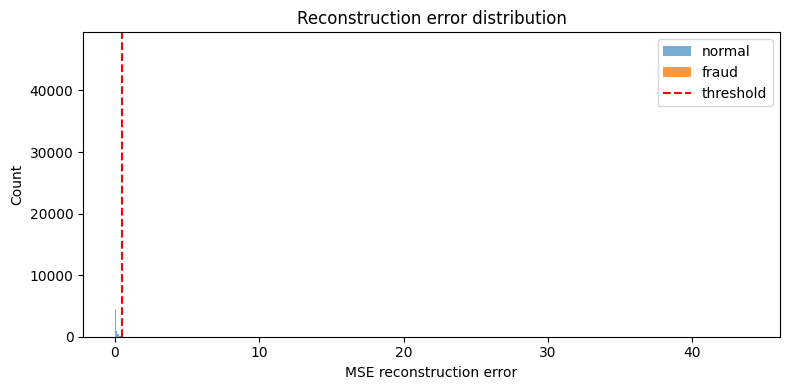

In [4]:
# ae_fraud.py
import os
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, precision_recall_fscore_support, confusion_matrix
import torch
from torch import nn, optim
from torch.utils.data import DataLoader, TensorDataset
import matplotlib.pyplot as plt

# === Config ===
DATA_PATH = "./data/creditcard.csv"   # place downloaded dataset next to script
BATCH_SIZE = 1024
LR = 1e-3
EPOCHS = 30
LATENT_DIM = 16
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
MODEL_PATH = "autoencoder_fraud.pth"

# === Load data ===
df = pd.read_csv(DATA_PATH)
# keep features V1..V28 + Amount
features = [c for c in df.columns if c not in ("Class", "Time")]
X = df[features].values
y = df["Class"].values

# === Preprocess ===
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Split: train only on normal samples
X_train_all, X_test, y_train_all, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)

# Training set: only normal transactions
X_train = X_train_all[y_train_all == 0]
# Create small validation set from normal data
X_train, X_val = train_test_split(X_train, test_size=0.1, random_state=42)

train_loader = DataLoader(TensorDataset(torch.tensor(X_train, dtype=torch.float32)),
                          batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(TensorDataset(torch.tensor(X_val, dtype=torch.float32)),
                        batch_size=BATCH_SIZE, shuffle=False)

# === Autoencoder model ===
class Autoencoder(nn.Module):
    def __init__(self, input_dim, latent_dim):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 64),
            nn.ReLU(),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Linear(32, latent_dim)
        )
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 32),
            nn.ReLU(),
            nn.Linear(32, 64),
            nn.ReLU(),
            nn.Linear(64, input_dim)
        )

    def forward(self, x):
        z = self.encoder(x)
        out = self.decoder(z)
        return out

model = Autoencoder(input_dim=X_scaled.shape[1], latent_dim=LATENT_DIM).to(DEVICE)
optimizer = optim.Adam(model.parameters(), lr=LR)
criterion = nn.MSELoss()

# === Training loop ===
best_val = float("inf")
for epoch in range(1, EPOCHS+1):
    model.train()
    train_loss = 0.0
    for (batch,) in train_loader:
        batch = batch.to(DEVICE)
        recon = model(batch)
        loss = criterion(recon, batch)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        train_loss += loss.item() * batch.size(0)
    train_loss /= len(train_loader.dataset)

    # validation (normal samples)
    model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for (batch,) in val_loader:
            batch = batch.to(DEVICE)
            recon = model(batch)
            loss = criterion(recon, batch)
            val_loss += loss.item() * batch.size(0)
    val_loss /= len(val_loader.dataset)

    if val_loss < best_val:
        best_val = val_loss
        torch.save(model.state_dict(), MODEL_PATH)

    print(f"Epoch {epoch:02d} train_loss={train_loss:.6f} val_loss={val_loss:.6f}")

# === Load best model ===
model.load_state_dict(torch.load(MODEL_PATH))
model.eval()

# === Compute reconstruction error on test set (includes fraud) ===
X_test_tensor = torch.tensor(X_test, dtype=torch.float32).to(DEVICE)
with torch.no_grad():
    recon_test = model(X_test_tensor).cpu().numpy()

recon_error = np.mean((recon_test - X_test)**2, axis=1)  # MSE per sample

# Save errors
np.save("recon_error.npy", recon_error)
np.save("y_test.npy", y_test)

# === Choose threshold: use ROC AUC and show PR metrics at chosen percentile ===
auc = roc_auc_score(y_test, recon_error)
print("ROC AUC (reconstruction error):", auc)

# Option 1: choose threshold at 99.5 percentile of reconstruction error on validation normal data
# compute validation errors:
X_val_tensor = torch.tensor(X_val, dtype=torch.float32).to(DEVICE)
with torch.no_grad():
    recon_val = model(X_val_tensor).cpu().numpy()
val_error = np.mean((recon_val - X_val)**2, axis=1)
thr = np.percentile(val_error, 99.5)
print("Threshold (99.5 pct of normal val):", thr)

y_pred = (recon_error > thr).astype(int)

prec, recall, f1, _ = precision_recall_fscore_support(y_test, y_pred, average="binary", zero_division=0)
cm = confusion_matrix(y_test, y_pred)
print("Precision:", prec, "Recall:", recall, "F1:", f1)
print("Confusion matrix:\n", cm)

# Plot histograms of reconstruction error
plt.figure(figsize=(8,4))
plt.hist(recon_error[y_test==0], bins=200, alpha=0.6, label="normal")
plt.hist(recon_error[y_test==1], bins=200, alpha=0.8, label="fraud")
plt.axvline(thr, color='red', linestyle='--', label='threshold')
plt.legend()
plt.title("Reconstruction error distribution")
plt.xlabel("MSE reconstruction error")
plt.ylabel("Count")
plt.tight_layout()
plt.savefig("recon_error_hist.png", dpi=150)
print("Saved recon_error_hist.png")
